# Text Classification with TF-IDF, LSTM, BERT: a comparison of performance

While looking for information to solve a text classification problem, I could find various descriptions on how to do it; but I was missing a comparison with measurable metrics, showing the pros and cons of various methods.

## Introduction

The objective of this article is to provide quantitative comparison of the algorithms, provide the Python code to make it, and basic explanations on what is being done.

The algorithms will be analysed using two metrics: accuracy and running time (for learning).

We will go over three text classification approaches, increasing in complexity and following the historical developments. First, we will use a "traditional" machine learning method, applying a linear model on the TF-IDF approach. Then we will go deep learning. We will first use a Recurrent Neural Network (RNN) method and encode words using the algorithm Word2Vec. This is a way of using pre-learned information. Finally, we will use the model BERT (or a simplified version of it, distil-BERT) and fine-tune it on our specific classification task. This approach allows the use of a pre-learned algorithm, which encodes not only words but entire sentences.

Note that we will use a very basic accuracy calculation. More sophisticated approaches (f-score, macro-average) would make more sense. But the goal of this article is to better understand classification models, not accuracy scores.

Before starting, we need to get the libraries:

In [ ]:
# from tensorflow.keras import layers를 추가하여 커스텀 레이어(Attention)를 만들 수 있도록 하였습니다.
# !pip install gensim을 추가하여 import gensim을 실행하기 위한 gensim 라이브러리를 설치하였습니다.

In [ ]:
# Data processing
import pandas as pd
import numpy as np

# Machine Learning
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelBinarizer

import tensorflow as tf
from tensorflow.keras import preprocessing as kprocessing
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras import layers # 커스텀 레이어(Attention)를 만들기 위함

import transformers

# Visualization
import matplotlib
from matplotlib import pyplot as plt

# Text processing
import re
import nltk
!pip install gensim # import gensim을 실행하기 위한 gensim 라이브러리 설치
import gensim
import gensim.downloader as api

# Various
from datetime import datetime

# Showing the versions used
print('Pandas version: {}'.format(pd.__version__))
print('Numpy version: {}'.format(np.__version__))
print('PyPlot version: {}'.format(matplotlib.__version__))
print('Scikit Learn version: {}'.format(sklearn.__version__))
print('Tensorflow version: {}'.format(tf.__version__))
print('Transformers version: {}'.format(transformers.__version__))
print('Regex version: {}'.format(re.__version__))
print('NLTK version: {}'.format(nltk.__version__))
print('Gensim version: {}'.format(gensim.__version__))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.2 MB/s eta 0:00:00
Pandas version: 2.2.2
Numpy version: 2.0.2
PyPlot version: 3.10.0
Scikit Learn version: 1.6.1
Tensorflow version: 2.19.0
Transformers version: 4.57.2
Regex version: 2.2.1
NLTK version: 3.9.1
Gensim version: 4.4.0


## Get and Process the Data

In this article we will consider two datasets (long texts and short texts):
- BBC news, classified by topic: https://www.kaggle.com/sainijagjit/bbc-dataset
- Tweets related to Corona, classified by sentiment (5 levels): https://www.kaggle.com/datatattle/covid-19-nlp-text-classification

We will use the BBC news throughout this article, but the same applies to the tweets dataset. The detailed analysis below relates to the BBC news use case. A detailed analysis of the Corona corpus might lead to different conclusions, given its complexity is higher and the dataset is larger.

Note that the BBC news corpus contains around 2k entries, and the Corona Tweets contain around 40k. The first dataset is therefore much faster and can be run on a standard computer, while the second dataset cannot.

In [ ]:
# 데이터셋 로드를 위해 datasets 라이브러리를 설치하고 huggingface 사이트의 AG News 데이터셋을 로드했습니다.

In [ ]:
!pip install datasets # 데이터셋 로드를 위한 datasets 라이브러리 설치

# Select the dataset for the analysis

from datasets import load_dataset # 데이터셋 로드 (AG News)

dataset = load_dataset("fancyzhx/ag_news") # 과제에서 주어진 huggingface 데이터셋 로드

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
# 사용하기 편하게 데이터셋을 Pandas DataFrame으로 변환했습니다.
# 숫자로 된 라벨을 텍스트로 바꿔줍니다(매핑).
# 기존 코드는 Train/Test가 나뉘어 있지 않아 CSV를 읽어와서 train_test_split을 했지만
# 과제 요건인 AG News는 이미 Train/Test가 나뉘어져 있으므로, 이를 concat를 통해 합쳤습니다.

In [ ]:
# Pandas DataFrame으로 변환
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

# 숫자 라벨을 텍스트 카테고리로 매핑 (0: World news, 1: Sports news, 2: Business news, 3: Science/Technology news)
label_map = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

df_train['category'] = df_train['label'].map(label_map)
df_test['category'] = df_test['label'].map(label_map)

df = pd.concat([df_train, df_test], ignore_index=True) # Train/Test로 나뉘어진 것을 concat를 통해 합침
df = df[['category', 'text']]

df.head()

,category,text
0,Business,Wall St. Bears Claw Back Into the Black (Reute...
1,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Business,Iraq Halts Oil Exports from Main Southern Pipe...
4,Business,"Oil prices soar to all-time record, posing new..."


### Analyze Data

Let's look at what we get.

In [ ]:
# 그대로 사용합니다. 전체 데이터셋(Train 120k+Test dataset 7.6k = 127.6k)의 수와 카테고리 별 데이터셋의 수를 확인했습니다.

In [ ]:
print('Total number of news: {}'.format(len(df)))
print(40*'-')
print('Split by category:')
print(df['category'].value_counts())
print(40*'-')
nr_categories = len(df['category'].unique())
print("Number of categories: {n}".format(n=nr_categories))

Total number of news: 127600
----------------------------------------
Split by category:
category
Business    31900
Sci/Tech    31900
Sports      31900
World       31900
Name: count, dtype: int64
----------------------------------------
Number of categories: 4


We get a total number of entries of 2'225, which are relatively evenly split across five categories.

In case the split across categories is imbalanced, there are techniques to "correct" this by over-weighting the data with an under-represented category. For this, you can refer to: https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

Finally, let's look at a specific example to get a concrete impression:

In [ ]:
# 그대로 사용합니다. huggingface 사이트의 100번째 데이터를 직접 눈으로 비교하여 Category와 Text가 맞는지 확인했습니다.

In [ ]:
# You can adjust n:
n=100
print('Category: ',df['category'][n])
print(100*'-')
print('Text:')
print(df['text'][n])

Category:  Sci/Tech
----------------------------------------------------------------------------------------------------
Text:
Comets, Asteroids and Planets around a Nearby Star (SPACE.com) SPACE.com - A nearby star thought to harbor comets and asteroids now appears to be home to planets, too. The presumed worlds are smaller than Jupiter and could be as tiny as Pluto, new observations suggest.


### Prepare Data

Some algorithms (RNN and based on BERT) are fed with the original text. But for the TF-IDF algorithm we need to pre-process the data.

We pre-process the data with the help of specialized libraries. We introduce a function that will allow to:
- convert to lower cases, remove special characters, ...
- tokenize (i.e. convert from strings to lists of words)
- remove stopwords (i.e. remove common words that bring noise to the system, like 'a', 'the', ...)
- stemm (i.e. remove -ing, -ly, ..., like convert 'making' to 'make', so that words with same meaning are identified as being the same)
- lemmatize (i.e convert the word into a root word, for example 'feet' becomes 'foot')

In [ ]:
# TF-IDF는 과제에서 다루지 않아, 에러 해결용으로 NLTK 불용어 데이터만 다운로드했습니다.
# 나머지 코드는 그대로 사용할 것이므로, TF-IDF 코드 부분은 이제 코멘트도 스킵하겠습니다.

In [ ]:
# Reference: Text Classification with NLP: Tf-Idf vs Word2Vec vs BERT from Medium

# 에러 해결용 NLTK 불용어 데이터 다운로드
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

# Use stopwords list from nltk (that is used in the function below)
lst_stopwords = nltk.corpus.stopwords.words("english")

def utils_preprocess_text(text, flg_stemm=False, flg_lemm=True, lst_stopwords=None):
    # Clean (convert to lowercase and remove punctuations and characters and then strip)
    # The function is not optimized for speed but split into various steps for pedagogical purpose
    text = str(text).lower()
    text = text.strip()
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize (convert from string to list)
    lst_text = text.split()
    # remove Stopwords
    if lst_stopwords is not None:
        lst_text = [word for word in lst_text if word not in lst_stopwords]

    # Stemming (remove -ing, -ly, ...)
    if flg_stemm == True:
        ps = nltk.stem.porter.PorterStemmer()
        lst_text = [ps.stem(word) for word in lst_text]

    # Lemmatisation (convert the word into root word)
    if flg_lemm == True:
        lem = nltk.stem.wordnet.WordNetLemmatizer()
        lst_text = [lem.lemmatize(word) for word in lst_text]

    # back to string from list
    text = " ".join(lst_text)
    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# Let's apply this function to the whole corpus
df["text_clean"] = df["text"].apply(lambda x: utils_preprocess_text(x, flg_stemm=False, flg_lemm=True, lst_stopwords=lst_stopwords))

# Let's look at the output
df.head()

,category,text,text_clean
0,Business,Wall St. Bears Claw Back Into the Black (Reute...,wall st bear claw back black reuters reuters s...
1,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...
2,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...
3,Business,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halt oil export main southern pipeline re...
4,Business,"Oil prices soar to all-time record, posing new...",oil price soar alltime record posing new menac...


The pre-processing makes the text less readable for a human but more readable for a machine!

### Split into Train and Test data

As a next step, in order to assess the accuracy of the algorithm, we need to split the dataset into a training dataset (to train the model) and a test dataset (to assess the model). This is done with standard tools. We split 70/30, as is standard for relatively small datasets.

We rename the input (text) to X and the output (category) to y, to be aligned with standard notations in machine learning.

The dataset is relatively small. Therefore it makes sense to create training/test sets that are representative of the dataset. We do it by splitting such that the number of dataset per category is similar. To understand this, think about forecasts for an election: you also need to take a sample that is representative of the population (representative by gender, age, ...)

In [ ]:
# Renaming, Input -> X, Output -> y
X = df['text_clean']
y = df['category']

In [ ]:
# Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=df['category'])

Let's look at the split by category: you can see that both the training and test sets are representative of the dataset.

In [ ]:
y_train.value_counts()/y.value_counts()

,count
category,
Business,0.7
Sci/Tech,0.7
Sports,0.7
World,0.7


## TF-IDF Model

The TF-IDF model (Term Frequency - Inverse Document Frequency) models a text by counting how often a word (called uni-gram), or a combination of two words (two successive words, called bi-gram), or even more (n-gram), appears in the text. This leads to the "term frequency". It is then divided by the document frequency, which counts how often a word appears across all entries (i.e. all documents). The last step allows to underweight words which appear more often, and overweight words which appear rarely.

The TF-IDF model does not take into account the order of the words (except for two successive words) and belongs therefore to the family of models called "Bag of Words". We will see later models which take the order of words into account.

To convert text into this format, we "vectorize" the text into a vector. When doing this we specify the size of the vocabulary (i.e. the total number of words taken into consideration), and the n-gram range. Then a word (and a word pair in case of bi-grams) is represented by a vector of the size of the vocabulary and has values in only one element, the others being all zero. This is called a one-hot vector.

After having initialized the vectorizer, we fit it on the entire training set.

In [ ]:
corpus = X_train
# Initizalize the vectorizer with max nr words and ngrams (1: single words, 2: two words in a row)
vectorizer_tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2))
# Fit the vectorizer to the training data
vectorizer_tfidf.fit(corpus)

TfidfVectorizer(max_features=15000, ngram_range=(1, 2))

Let's build the model. After an entry is converted to a vector using the vectorizer, we apply an algorithm that minimizes the error, i.e. the output predicted by the model y(X) should be as often as possible equal to the label y.

We use the logistics regression. Other models could also be applied (like SVM, Naive Bayes, ...).

We build the model as a pipeline, consisting of:
- vectorization
- classifier

After initialization of the model, we fit it to the training data.

In [ ]:
classifier_tfidf = LogisticRegression()
model_tfidf = Pipeline([("vectorizer", vectorizer_tfidf), ("classifier", classifier_tfidf)])

start_time = datetime.now()
model_tfidf.fit(X_train, y_train)
end_time = datetime.now()

training_time_tfidf = (end_time - start_time).total_seconds()

After the model is trained, we assess the accuracy of the model by comparing the predictions of the model to the labels for both the training and the test data. We compare it for both as the difference between the two accuracies is an important indicator of overfitting (i.e. the model is too strongly fitted to the training data).

We also look at the duration of the training.

In [ ]:
predicted_train_tfidf = model_tfidf.predict(X_train)
accuracy_train_tfidf = accuracy_score(y_train, predicted_train_tfidf)
print('Accuracy Training data: {:.1%}'.format(accuracy_train_tfidf))

predicted_test_tfidf = model_tfidf.predict(X_test)
accuracy_test_tfidf = accuracy_score(y_test, predicted_test_tfidf)
accuracy_tfidf = accuracy_test_tfidf
print('Accuracy Test data: {:.1%}'.format(accuracy_test_tfidf))

print('Training time: {:.1f}s'.format(training_time_tfidf))

Accuracy Training data: 93.9%
Accuracy Test data: 91.5%
Training time: 36.1s


We get an amazing accuracy! Both training and test accuracy are similar, so the model is not overfitted. If the model were overfitted, it could be improved by adjusting the regularization, which comes by default with the sci-kit logistic regression model. A typical regularization mechanism is the L2 regularization, which is not covered in this article. And we got it in less than 3 seconds!

Before moving to deep learning, we would like to add a few comments on the Logistic Regression model. This model is to classification what linear regression is to regression. It is a linear model. This means that the minimization algorithm consists of minimizing a function which is quadratic in its parameters. The great news is that such a minimization has no local minima, but only a global minimum, which can be reached. And it can be reached using a simple and fast algorithm, by inverting a matrix (of the size of the vocabulary). The negative side is that once this minimum is reached, it is difficult to improve the model (except by adding regularization).

The conclusion is that the linear algorithm are converging fast and reach the "exact" solution, however once a model is optimized, there is little room for improvement.

### Model Interpretation

An advantage of the linear algorithm is that we can interpret its result easily. Since each parameter of the model corresponds to a word, knowing which parameters count most automatically tells us which words count most.

Let's have a closer look at the model's parameters, extracting the ten most important words per category:

In [ ]:
print('Classes of the model: ',classifier_tfidf.classes_)
print(80*'-')
print('Shape of the coefficients of the model (categories x vocabulary size): ',classifier_tfidf.coef_.shape)
print(80*'-')
NN = 10
# Get the 10 (here: NN, which you can adjust yourself) ids of the words with highest weights per category
top_words = np.argsort(classifier_tfidf.coef_,axis=1)[:,-NN:]

# Get the vocabulary of the model (mapping of words to ids):
voc = vectorizer_tfidf.vocabulary_
# Get the inverse vocabulary to map the ids of the words to the words:
inv_voc = {v: k for k, v in voc.items()}

# Get for each category (=class) the top ten words
for n, w in enumerate(classifier_tfidf.classes_):
    t = w + ': '
    for i in range(NN):
        t += inv_voc[top_words[n,i]]
        if i!=NN:
            t+=', '
    print(t)
    print(80*'-')

Classes of the model:  ['Business' 'Sci/Tech' 'Sports' 'World']
--------------------------------------------------------------------------------
Shape of the coefficients of the model (categories x vocabulary size):  (4, 15000)
--------------------------------------------------------------------------------
Business: inc, profit, economic, lta, airline, hellip, retailer, bank, oil, economy, 
--------------------------------------------------------------------------------
Sci/Tech: reuters reuters, apple, online, microsoft, technology, software, scientist, space, nasa, internet, 
--------------------------------------------------------------------------------
Sports: baseball, league, season, champion, player, stadium, sport, team, cup, coach, 
--------------------------------------------------------------------------------
World: athens greece, palestinian, president, hostage, nuclear, canadian press, leader, iraqi, afp, iraq, 
----------------------------------------------------------

The model seems to work well!

## Deep Learning - RNN

Words appear in a text in a given order. Recurrent Neural Networks (RNN) are models which take the order of words into account, by processing words sequentially, as they appear in the text. It was observed that RNNs, without any "internal memory", have a limitation regarding "how far they can remember" the effect of correlations between words. To mitigate this, Long Short Term Memory (LSTM) cells replaced the traditional RNNs in Machine Learning. The LSTM cells have internal variables which act as a memory. It comes at a slightly higher computational costs, which is typically acceptable.

In the building of this model, we take advantage of word embeddings, applying Word2Vec. This is a technique that was published in 2013 [1] and had a considerable impact in NLP. It consists of describing a word with a vector of a given size (typically 100 or 300). The vector for a given word is defined by its context within texts (i.e. based on words on its left and its right - N words on the left, N words on the right, N being typically 5). Typically, word embeddings is trained on huge text corpuses. Word2Vec was trained on millions of Google News, while a similar technique called GloVe was trained on Wikipedia. Words with similar meanings (synonyms) are typically close to each other in this space of words. The representation is "dense", compared to the one-hot vector representation, which is "sparse".

The sequential approach of RNN enables to take the order of words into account, but at the same time slows down the training, since a sequential approach by design cannot be handled by parallel computing.

Training and test data is defined in a different way than for TF-IDF: we will use the non-processed text. The labelling cannot be handled as text but has to be converted into a one-hot vector, because of technical reasons (to the best of my knowledge, this is simply not implemented in TensorFlow). Then we split into training and test data, same as we did for TF-IDF.

In [ ]:
# 그대로 사용합니다. # RNN 처리를 위한 데이터를 준비하기 위한 과정으로, 시퀀스로 변환하기 위한 One-hot Encoding 과정과
# 데이터셋을 다시 Train/Test로 split하는 것을 확인했습니다.

In [ ]:
# Renaming, Input -> X, Output -> y
X_tf = df['text']
y_tf_class = df['category']

# Convert labels into a one-hot vector of size 5 (the number of distinct labels)
lab = LabelBinarizer()
lab.fit(y_tf_class)
y_tf = lab.transform(y_tf_class)

# Example (you can modify n)
n=100
print('Coding of labels into a one-hot vector: ' + y_tf_class[n] + ' is ', y_tf[n])

# Split into training and test data
X_tf_train, X_tf_test, y_tf_train, y_tf_test = train_test_split(X_tf, y_tf, test_size=0.3, random_state=42, stratify=df['category'])

Coding of labels into a one-hot vector: Sci/Tech is  [0 1 0 0]


The text, a sequence of words, needs to be converted to a sequence of numbers. We tokenize the text using TensorFlow's tokenizer.

After initializing the tokenizer, we fit it on the training data.

In [ ]:
# 그대로 사용합니다. 토크나이저 설정 및 학습 과정임을 확인했습니다.

In [ ]:
corpus = X_tf_train
max_words = 15000
tokenizer = kprocessing.text.Tokenizer(lower=True, split=' ', num_words=max_words, oov_token="<pad>", filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(corpus)
voc = tokenizer.word_index
reverse_voc = dict([(value, key) for (key, value) in voc.items()])

Let's use the tokenizer to convert the training data (a sequence of words) into a sequence of numbers representing the words. We then pad sequences using TensorFlow's pad_sequences. We define a limit to the length of the sequences. Any text with more words than allowed will be cut.

We look at the shape of the training data after processing it, and illustrate it with a specific example.

In [ ]:
# 그대로 사용합니다. 각 단어를 고유한 정수로 변환하고, 모든 문장의 길이를 동일하게 맞춰주는 Padding 과정임을 확인했습니다.

In [ ]:
max_len = 200

sequences = tokenizer.texts_to_sequences(X_tf_train)
X_tf_train_seq = kprocessing.sequence.pad_sequences(sequences, maxlen=max_len)

# Apply the same to test data
X_tf_test_seq = kprocessing.sequence.pad_sequences(tokenizer.texts_to_sequences(X_tf_test), maxlen=max_len)

n=10 # You can adjust n
print('Shape: ',X_tf_train_seq.shape)
print(100*'-')
print('Example: ',X_tf_train_seq[n,:])

Shape:  (89320, 200)
----------------------------------------------------------------------------------------------------
Example:  [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0 2687  288 7699  895    3    1 1510 5258    4  722    7
  367  856  288 

Each word is now represented by a number (an index). We want to represent it by a vector which represents it best, leveraging on pre-learned information.

This is done using Word2Vec, which we have described above. We will not train ourselves this word representation but download an existing representation, from the library gensim. This may take several minutes. Once this word representation is available, we map it to our tokenization.

In [ ]:
# 그대로 사용합니다. Word2Vec을 모델을 다운로드 하는 것임을 확인했습니다.

In [ ]:
# This may take several minutes
w2v = api.load("word2vec-google-news-300")
# Example of a word representation:
w2v['hello'].shape

[==================================================] 100.0% 1662.8/1662.8MB downloaded


(300,)

In [ ]:
# 그대로 사용합니다. Word2Vec 모델을 사용하여 임베딩 행렬의 가중치를 구하는 과정임을 확인했습니다.

In [ ]:
# Build weights of the embbeddings matrix using w2v
emb_matrix=np.zeros((max_words+1, 300))
for i in range(max_words):
    w = reverse_voc[i+1]
    if w in w2v:
        emb_matrix[i+1,:] = w2v[w]
emb_size = emb_matrix.shape[1]

After we have a word representation, we build the model. We use:
- Input layer: to tell the model which input format to expect, so that the model knows what to expect
- Embedding: we transform the input (a sequence of word indices) into a sequence of embedded words (a sequence of vectors of size 300), using the downloaded Word2Vec matrix
- LSTM layer: we use an LSTM layer that goes in both directions (forward and backward), to have maximal information available. The output of this layer (that is pushed to the next layer) is the output of the last word (on the right for the forward LSTM, on the left for the backward LSTM). We set the size of the output vector to 15 (which is somewhat arbitrary). Combining both outputs (forward and backward), we get a vector of size 30
- Dropout layer: for regularization
- Dense layer (with relu activation function, with 64 neurons): to solve the specific problem of classification
- Dense layer (with softmax activation function): for a probability distribution for each label

We run the model using Adam optimizer, where we have played with the hyper-parameters. Based on the recommendations of the first article on dropout (2014) [2|, we increase the learning rate compared to TensorFlow's default values.

In [ ]:
# ★ Attetion layer 클래스를 정의하였습니다.

In [ ]:
# Attention ㅣayer 정의
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        # Attention 가중치(W)와 편향(b)을 학습 가능한 파라미터로 정의
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x shape : (batch_size, time_steps, features)

        # 1. 각 시점(time_step)의 중요도(Score) 계산 (tanh 활성화 함수 사용)
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)

        # 2. Score를 확률값(Attention Weights)으로 변환 (Softmax 사용)
        a = tf.keras.backend.softmax(e, axis=1)

        # 3. 입력값(x)에 가중치(a)를 곱해 중요한 정보만 강조하도록 함.
        output = x * a

        # 4. 가중 평균된 벡터들의 합(Context Vector)을 반환
        return tf.keras.backend.sum(output, axis=1)

In [ ]:
# 앞에서 정의한 Attention layer를 모델에 적용시켰습니다. 나머지 레이어(Embdding, LSTM, Dropout, Dense 등)은 그대로 사용합니다.
# 추가로, Attention을 적용하려면 모든 시점의 출력값이 필요하므로 LSTM Layer에서 return_sequences=True로 설정해야 합니다.

In [ ]:
input_ = layers.Input(shape = X_tf_train_seq[0,:].shape,name='input')
# Embedding layer (voc size plus un ("UNK", word with index 0)), using the pre-trained emb_matrix obtained from Word2Vec
x = layers.Embedding(max_words+1,emb_size,weights=[emb_matrix],trainable=False, name='embedding')(input_)
x = layers.Bidirectional(layers.LSTM(15,dropout=0.2, return_sequences=True),name='bidirectional-lstm')(x) # LSTM layer. return_sequences=True를 추가하여 Attention layer에 시퀀스를 전달
x = Attention(name='attention')(x) # Attention Layer: LSTM의 모든 출력을 받아 중요한 정보를 요약(Attention)
x = layers.Dropout(0.2, name='dropout')(x)
x = layers.Dense(64, activation='relu', name='dense')(x)
output = layers.Dense(nr_categories,activation='softmax', name='classification')(x)

model = models.Model(input_, output)

opt = optimizers.Adam(learning_rate=0.01, beta_1=0.9)
model.compile(optimizer=opt,loss='categorical_crossentropy', metrics=['accuracy'])

Let's look at the model:

In [ ]:
# 그대로 사용합니다. 모델의 레이어들이 잘 작동하는 것을 확인했습니다.

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 300)       │     4,500,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional-lstm              │ (None, 200, 30)        │        37,920 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 30)             │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,540,694 (17.32 MB)

 Trainable params: 40,394 (157.79 KB)

 Non-trainable params: 4,500,300 (17.17 MB)

Now it is time to train the model! We train it over 10 epochs. When training the model, we get from the history object precious information, that we display after the training.

In [ ]:
# 그대로 사용합니다. Attention 레이어를 추가한 RNN 모델을 학습시키는 과정임을 확인했습니다.

In [ ]:
start_time = datetime.now()
history = model.fit(X_tf_train_seq, y_tf_train, batch_size=64, shuffle=True, epochs=10, validation_data=(X_tf_test_seq, y_tf_test))
end_time = datetime.now()

training_time_rnn = (end_time - start_time).total_seconds()

Epoch 1/10
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 79s 46ms/step - accuracy: 0.8488 - loss: 0.4208 - val_accuracy: 0.9043 - val_loss: 0.2796
Epoch 2/10
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9046 - loss: 0.2793 - val_accuracy: 0.9089 - val_loss: 0.2662
Epoch 3/10
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.9122 - loss: 0.2541 - val_accuracy: 0.9127 - val_loss: 0.2544
Epoch 4/10
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.9172 - loss: 0.2414 - val_accuracy: 0.9121 - val_loss: 0.2546
Epoch 5/10
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9204 - loss: 0.2309 - val_accuracy: 0.9169 - val_loss: 0.2450
Epoch 6/10
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9204 - loss: 0.2276 - val_accuracy: 0.9178 - val_loss: 0.2430
Epoch 7/10
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.9240 - loss: 0.2209 - val_accuracy: 0.9168 - val_loss: 0.2447
Epoch 8/10
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.9255 -

In [ ]:
# 그대로 사용합니다. 모델 학습 후의 정보를 그래프로 나타내는 과정임을 확인했습니다.

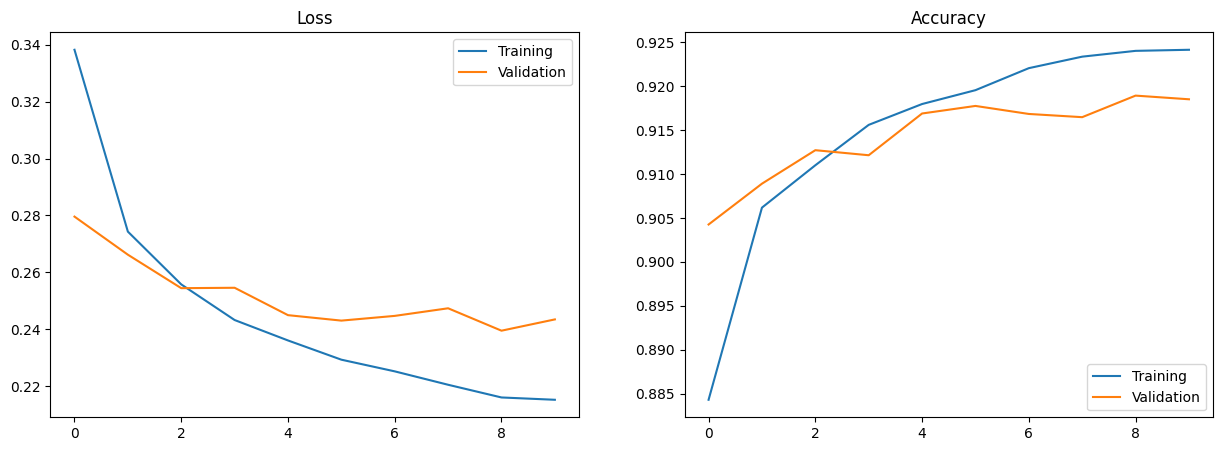

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax[0].set(title='Loss')
ax[0].plot(history.history['loss'], label='Training')
ax[0].plot(history.history['val_loss'], label='Validation')
ax[0].legend(loc="upper right")

ax[1].set(title='Accuracy')
ax[1].plot(history.history['accuracy'], label='Training')
ax[1].plot(history.history['val_accuracy'], label='Validation')
ax[1].legend(loc="lower right")

In [ ]:
# 그대로 사용합니다. 정확도(Accuracy)와 학습 시간을 출력하여 다른 모델들과 비교할 수 있음을 확인했습니다.

In [ ]:
accuracy_rnn = history.history['val_accuracy'][-1]
print('Accuracy Training data: {:.1%}'.format(history.history['accuracy'][-1]))
print('Accuracy Test data: {:.1%}'.format(history.history['val_accuracy'][-1]))
print('Training time: {:.1f}s'.format(training_time_rnn))

Accuracy Training data: 92.4%
Accuracy Test data: 91.9%
Training time: 375.2s


For this (simple) problem with little training data, we observe that this sophisticated model gets a lower accuracy than the TF-IDF model, and needs around 10 times more time to be trained!

This might be disappointing. My conclusion is:  a simple problem does not necessarily needs a sophisticated solution.

The Recurrent Neural Network model with the use of Word2Vec was improved from the Linear TF-IDF model by taking the order of words into consideration, and by using a pre-learned representation of words. But the representation of words we have does not consider the context in which the word is applied. For example, in the following sentences: "I took a loan at the bank.", "I am sitting on a bank.", the word "bank" has a completely different meaning. It is reasonable to think that teh context matters. This is what the model BERT is solving.

## Deep Learning - With Bert Language Model

Going one step further, let's introduce a model where not only each single words are pre-learned, but entire sentences. This is achieved with the BERT language model, which was published in 2019 by Devlin et al [3], at Google. This language model allows the encoding of words depending on their context, by using a huge corpus (Wikipedia and books) for training. Training is done as self-supervised: it is done by masking randomly words from existing sentences. The training of the model consists of completing the missing words. The architecture of BERT consists of multiple layers of transformers.
The BERT model has 110m parameters; the large Bert model has 340m parameters. In practice, we will use a smaller model, Distil Bert, which has 66m parameters.
Devlin at al. made the implementation of the BERT model available (https://github.com/google-research/bert). But we will use the Python library transformers, which was made available by company HuggingFace (together with many other models).

Since the BERT model is pre-trained, it comes with a tokenizer. This is why we will use the non-processed training data, and will tokenize the sentences using the Distil Bert tokenizer. As for the RNN model, we will have to map the labels to a one-hot vector.

For practical reasons, we will first convert the training data into the desired format, and later we will split into training/test data.

The Distil BERT model requires a sequence of word indices and an attention mask (a sequence of attention values). This is also what the Distil Bert tokenizer generates. But for our simple use case, the attention mask will be constant. This is why, when building the data, we will ignore the attention mask and only consider the word indices (which are the "input_ids" of the Distil Bert tokenizer). For performance reasons, we convert the list of training data into an array.

In [ ]:
# distillbert 부분의 코드들은 대부분 수정없이 그대로 사용합니다.
# 단, 문장 길이를 그대로 512로 설정하면 모델 학습이 너무 오래걸려서
# 처리 속도와 메모리 절약을 위해 문장 길이를 128로 설정하여 진행하겠습니다.
# 추가로, 중간에 오류가 발생하는 부분(호환성, 타입 검사 문제 등)만 간단히 수정하였습니다.

In [ ]:
# Renaming, Input -> X, Output -> y
X_bert = df['text']
y_bert_class = df['category']

# Convert labels into a one-hot vector of size 5 (the number of distinct labels)
lab = LabelBinarizer()
lab.fit(y_bert_class)
y_bert = lab.transform(y_bert_class)

# Example (you can modify n)
n=100
print('Coding of labels into a one-hot vector: ' + y_bert_class[n] + ' is ', y_bert[n])

Coding of labels into a one-hot vector: Sci/Tech is  [0 1 0 0]


In [ ]:
# 처리 속도와 메모리 절약을 위해 문장 길이를 512 -> 128로 설정하였습니다.

In [ ]:
# distil-bert tokenizer
tokenizer_bert = transformers.DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
X_bert = [tokenizer_bert(text, padding='max_length', max_length = 128, truncation=True)['input_ids'] for text in X_bert]
X_bert = np.array(X_bert, dtype='int32')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Let's split the data into a training and a test set, and have a look at the format of the data.

In [ ]:
# 그대로 사용합니다.

In [ ]:
# Train/test split
X_bert_train, X_bert_test, y_bert_train, y_bert_test = train_test_split(X_bert, y_bert, test_size=0.3, random_state=42, stratify=df['category'])
print('Shape of training data: ',X_bert_train.shape)

Shape of training data:  (89320, 128)


Let's define the Distil Bert model, using a pre-trained model from the transformers library. This model will be integrated as a layer in the classification model. We will not train the parameters of this layer, which we do by setting it as trainable=False.

In [ ]:
# from_pretrained 함수 호출 시 호환성 문제로 실행 오류가 발생하여,
# use_safetensors=False 옵션을 추가하여 해결하였습니다.

In [ ]:
config = transformers.DistilBertConfig(dropout=0.2, attention_dropout=0.2)
dbert = transformers.TFDistilBertModel.from_pretrained('distilbert-base-uncased', config=config, trainable=False, use_safetensors=False)

tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertModel: ['vocab_projector', 'vocab_transform', 'activation_13', 'vocab_layer_norm']
- This IS expected if you are initializing TFDistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFDistilBertModel were initialized from the model checkpoint at distilbert-base-uncased.
If your task is similar to the task the model of the checkpoint was

You might get a warning message. Don't worry about it. In the context where we apply the model, this message can be ignored.

Let's have a closer look at the output of this model. For this, let's take a sample from our training dataset (we take a sample of size five) and look at the output through the model.

In [ ]:
# Let's create a sampe of size 5 from the training data
sample = X_bert_train[0:5]
print('Object type: ', type(dbert(sample)))
print('Output format (shape): ',dbert(sample)[0].shape)
print('Output used as input for the classifier (shape): ', dbert(sample)[0][:,0,:].shape)

Object type:  <class 'transformers.modeling_tf_outputs.TFBaseModelOutput'>
Output format (shape):  (5, 128, 768)
Output used as input for the classifier (shape):  (5, 768)


The output is a specific Python object. Among other information, we get a Tensor of size (N, M, S), where N is the size of the dataset (in our case five examples), M is the length of the sample (number of words in a sentence), and S is the size of the output vector (the output of the model). Typically, as mentioned by Devlin et al., for a classification task, we use the first output vector of a sentence as input for the rest of the classification model, since this first vector "encodes" information on the overall sentence. Alternatively a pooling of all output vectors could also be used as input for the rest of the classifier.

It is now time to build the classification model! It consists of:
- Input layer: to tell the model which input format to expect, so that the model knows what to expect
- Distil Bert model: to encode the input data into a new sequence of vectors (that is the output of BERT). Only the first vector of this sequence will be used as an input for the rest of the classifier
- Dropout layer: for regularization
- Dense layer (with relu activation function, with 64 neurons): to solve the specific problem of classification
- Dense layer (with softmax activation function): for a probability distribution for each label

In [ ]:
# transform 라이브러리 내부에 엄격한 타입 검사로 인한 실행 오류가 발생하여
# dbert 호출을 Lamda 레이어로 감싸 KerasTensor가 간접적으로 처리되도록 하였습니다.

In [ ]:
input_ids_in = layers.Input(shape=(128,), name='input_token', dtype='int32') # 문장 길이 512 -> 128

# dbert 호출을 Lamda 레이어로 감싸 KerasTensor가 간접적으로 처리되도록 함
x = layers.Lambda(lambda ids: dbert(input_ids=ids)[0][:,0,:], output_shape=(768,))(input_ids_in)
x = layers.Dropout(0.2, name='dropout')(x)
x = layers.Dense(64, activation='relu', name='dense')(x)
x = layers.Dense(nr_categories, activation='softmax', name='classification')(x) # Use nr_categories which is 4

dmodel = models.Model(inputs=input_ids_in, outputs = x)

dmodel.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# 그대로 사용했으나 기존 코드로 실행했을 때와 파라미터 수의 차이가 많이 나서
# 분석해본 결과 오류 해결을 위해 dbert를 Lamda 레이어로 감싸는 과정에서
# Lamda 레이어 내부에서 호출되는 외부 모델(dbert)의 함수는 자동으로 계산하지 않기
# 때문입니다. 하지만 dbert는 여전히 모든 파라미터를 가지고 있으며 실제 계산에도
# 사용되고 있습니다. 이는 dbert.summary()를 통해 확인할 수 있었습니다.

In [ ]:
dmodel.summary()
dbert.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_token (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,476 (193.27 KB)

 Trainable params: 49,476 (193.27 KB)

 Non-trainable params: 0 (0.00 B)

Model: "tf_distil_bert_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
Total params: 66362880 (253.15 MB)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 66362880 (253.15 MB)
_________________________________________________________________


In [ ]:
# 그대로 사용했습니다. 최대 길이를 512 -> 128로 조정하니 학습 시간은 확실히 줄어들었으나 정확도가 조금 떨어지는 것을 확인했습니다.

In [ ]:
# Train the model
start_time = datetime.now()
history = dmodel.fit(X_bert_train, y_bert_train, batch_size=32, shuffle=True, epochs=5, validation_data=(X_bert_test, y_bert_test))
end_time = datetime.now()

training_time_bert = (end_time - start_time).total_seconds()

Epoch 1/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 503s 176ms/step - accuracy: 0.8497 - loss: 0.4315 - val_accuracy: 0.8900 - val_loss: 0.3128
Epoch 2/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 484s 173ms/step - accuracy: 0.8831 - loss: 0.3252 - val_accuracy: 0.8842 - val_loss: 0.3280
Epoch 3/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 484s 173ms/step - accuracy: 0.8898 - loss: 0.3125 - val_accuracy: 0.8971 - val_loss: 0.2877
Epoch 4/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 484s 173ms/step - accuracy: 0.8906 - loss: 0.3013 - val_accuracy: 0.8969 - val_loss: 0.2838
Epoch 5/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 484s 173ms/step - accuracy: 0.8923 - loss: 0.2967 - val_accuracy: 0.8992 - val_loss: 0.2790


In [ ]:
# 그대로 사용했습니다. 정확도가 다소 아쉽지만 Epoch이 증가할수록 정확도도 증가함을 확인했습니다.

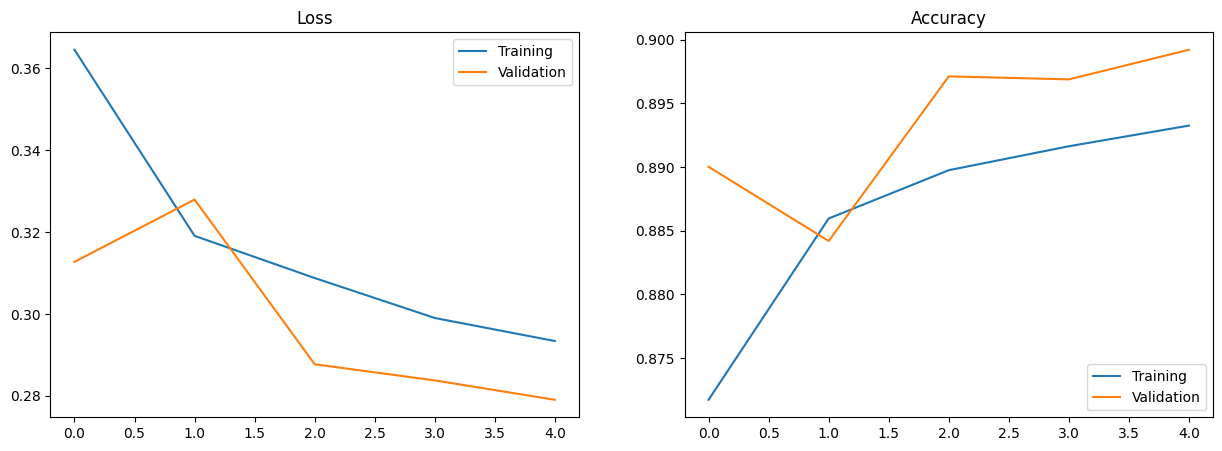

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax[0].set(title='Loss')
ax[0].plot(history.history['loss'], label='Training')
ax[0].plot(history.history['val_loss'], label='Validation')
ax[0].legend(loc="upper right")

ax[1].set(title='Accuracy')
ax[1].plot(history.history['accuracy'], label='Training')
ax[1].plot(history.history['val_accuracy'], label='Validation')
ax[1].legend(loc="lower right")

In [ ]:
# 그대로 사용했습니다. 정확도와 학습 시간을 확인할 수 있습니다.

In [ ]:
accuracy_bert = history.history['val_accuracy'][-1]
print('Accuracy Training data: {:.1%}'.format(history.history['accuracy'][-1]))
print('Accuracy Test data: {:.1%}'.format(history.history['val_accuracy'][-1]))
print('Training time: {:.1f}s (or {:.1f} minutes)'.format(training_time_bert, training_time_bert/60))

Accuracy Training data: 89.3%
Accuracy Test data: 89.9%
Training time: 2438.7s (or 40.6 minutes)


For this (simple) problem with little training data, we observe that this sophisticated model gets a lower accuracy than the TF-IDF model, and needs more than 2'000 times more time to be trained!

This might be disappointing. Same as for the RNN model, my conclusion is: a simple problem does not necessarily needs a sophisticated solution.

## Conclusion

We have gone through three Machine Learning models to classify news according to their category. We have increased the complexity of the models, starting with a "classical" machine learning model, a linear model using TF-IDF. Then we have used a Recurrent Neutral Network model, using word embeddings to make use of pre-learned information. Finally we have used a BERT model, which is a pre-trained model, having not only single words pre-trained but also entire sentences.
The models used are:
- Linear model TF-IDF
- Bi-directional LSTM model with word2vec word embedding
- Distil BERT

We have measured these models using two metrics:
- Acurracy
- Training time
Let's look at the results:

In [ ]:
# 그대로 사용했습니다. 모델 별로 정확도와 학습 시간을 확인했습니다.

In [ ]:
method = ['TF-IDF', 'RNN', 'BERT']
accuracy = [accuracy_tfidf, accuracy_rnn, accuracy_bert]
accuracy = [str(round(acc*100, 1))+'%' for acc in accuracy]
training_time = [round(training_time_tfidf,1), round(training_time_rnn,1), round(training_time_bert,1)]
training_time_rounded = [round(tt,1) for tt in training_time]
training_time = np.array(training_time)
training_time_x = list(training_time /min(training_time))
training_time_x = [str(round(ttx,1))+'x' for ttx in training_time_x]

dict = {'Method' : method,
        'Accuracy' : accuracy,
        'Training Time [s]' : training_time_rounded,
        'Training Time [x]' : training_time_x}
df = pd.DataFrame(dict)
display(df)

,Method,Accuracy,Training Time [s],Training Time [x]
0,TF-IDF,91.5%,36.1,1.0x
1,RNN,91.9%,375.2,10.4x
2,BERT,89.9%,2438.7,67.6x


This classification is a simple problem. A simple model like the linear TF-IDF model already provides a very good accuracy. Using more complex models does not improve accuracy, but costs much more time: the RNN model needs 20 times more time than the TF-IDF. The BERT model needs even more than 1'000 times more time than the TF-IDF!

My conclusion is: it is not always necessary to use complex models, if simple models already solve the issue!

As a side note: the Linear TF-IDF approach can be very frustrating, if we do not get a satisfying accuracy from the beginning. In such cases it can be very hard to improve the model. It is very different with RNN and BERT models. Such models can be easily improved: one can either develop a more sophisticated architecture of the model, or run the model on more epochs, ... For the BERT model, it is fascinating to see that at each epoch, the accuracy improves. One might feel that the model reads the text better and better.

## References

[1] Mikolov, Tomas, et al. (2013). "Efficient Estimation of Word Representations in Vector Space"

[2] Srivastava, Hinton et al. (2014). "Dropout: A Simple Way to Prevent Neural Networks from Overfitting"

[3] Devlin et al. (2019). "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding"